# Simulated Annealing 模拟退火

## 本 Notebook 的教学目标

1. 在经典 TSP 场景下理解该算法的工作机制。
2. 完成一个从零实现版本，而不是只调用现成库。
3. 通过路径图、收敛曲线、统计结果观察算法行为。
4. 为下个月授课准备可直接展示的实验材料。

## 为什么选 TSP

模拟退火最经典的教学案例之一就是 **TSP**。因为路径长度是直观的，而“偶尔接受更差路径”也能直接在路径图上看出来。

TSP 的优点是：**结果是可视化路径，过程也是可视化路径**。因此它非常适合课堂讲解组合优化算法。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque

# 统一图表风格，保证不同 Notebook 的视觉体验一致。
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


# 为了让路径图更直观，这里统一生成二维城市坐标。

def make_cities(n_cities=20, seed=7):
    rng = np.random.default_rng(seed)
    return rng.uniform(0, 100, size=(n_cities, 2))


def pairwise_distances(cities):
    diff = cities[:, None, :] - cities[None, :, :]
    return np.sqrt((diff ** 2).sum(axis=2))


def route_length(route, distance_matrix):
    rolled = np.roll(route, -1)
    return float(distance_matrix[route, rolled].sum())


def plot_route(cities, route, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    ordered = cities[route]
    closed = np.vstack([ordered, ordered[0]])
    ax.plot(closed[:, 0], closed[:, 1], '-o', color='#1f77b4', lw=2, ms=6)
    for idx, (x, y) in enumerate(cities):
        ax.text(x + 1, y + 1, str(idx), fontsize=10)
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    return ax


def two_opt_swap(route, i, j):
    new_route = route.copy()
    new_route[i:j] = route[i:j][::-1]
    return new_route


def random_route(rng, n_cities):
    return rng.permutation(n_cities)


def summarize_runs(scores):
    return pd.Series({
        'best': float(np.min(scores)),
        'mean': float(np.mean(scores)),
        'worst': float(np.max(scores)),
        'std': float(np.std(scores)),
    })


# 固定城市坐标，保证不同算法 Notebook 之间有可比性。
cities = make_cities(n_cities=20, seed=11)
distance_matrix = pairwise_distances(cities)

## 算法直觉

核心思想：在高温阶段更愿意接受较差解，从而跳出局部最优；温度逐渐降低后，算法会越来越保守，最终稳定下来。

在讲课时，可以把这个算法与“纯贪心”或“纯随机搜索”对照起来讲，学生更容易抓住重点。

In [2]:
def propose_route(route, rng):
    # 使用区间反转作为邻域操作，这是 TSP 中非常常见且直观的变换方式。
    i, j = sorted(rng.choice(len(route), size=2, replace=False))
    if i == j:
        j = min(len(route), i + 1)
    return two_opt_swap(route, i, j), (i, j)


def simulated_annealing(distance_matrix, n_iterations=2000, initial_temperature=120, cooling_rate=0.995, seed=0):
    rng = np.random.default_rng(seed)
    current = random_route(rng, len(distance_matrix))
    current_length = route_length(current, distance_matrix)

    best = current.copy()
    best_length = current_length

    current_lengths = [current_length]
    best_lengths = [best_length]
    accepted_flags = []
    snapshots = [(0, current.copy())]
    temperature = initial_temperature

    for iteration in range(1, n_iterations + 1):
        candidate, _ = propose_route(current, rng)
        candidate_length = route_length(candidate, distance_matrix)
        delta = candidate_length - current_length

        # 退火准则：如果更优则直接接受；如果更差，则按温度控制的概率接受。
        if delta < 0 or rng.random() < np.exp(-delta / max(temperature, 1e-9)):
            current = candidate
            current_length = candidate_length
            accepted_flags.append(1)
        else:
            accepted_flags.append(0)

        if current_length < best_length:
            best = current.copy()
            best_length = current_length

        current_lengths.append(current_length)
        best_lengths.append(best_length)

        if iteration in {1, 50, 200, 600, 1200, 2000}:
            snapshots.append((iteration, current.copy()))

        temperature *= cooling_rate

    return {
        'best_route': best,
        'best_length': float(best_length),
        'current_lengths': np.array(current_lengths),
        'best_lengths': np.array(best_lengths),
        'accepted_flags': np.array(accepted_flags),
        'snapshots': snapshots,
    }

## 单次实验演示

下面先做一次完整实验。建议课堂上先关注：

1. 初始路径和最终路径差别有多大。
2. 收敛过程中是否存在明显跳跃。
3. 算法是否会在早期快速改进、后期缓慢收敛。

best route length: 381.482


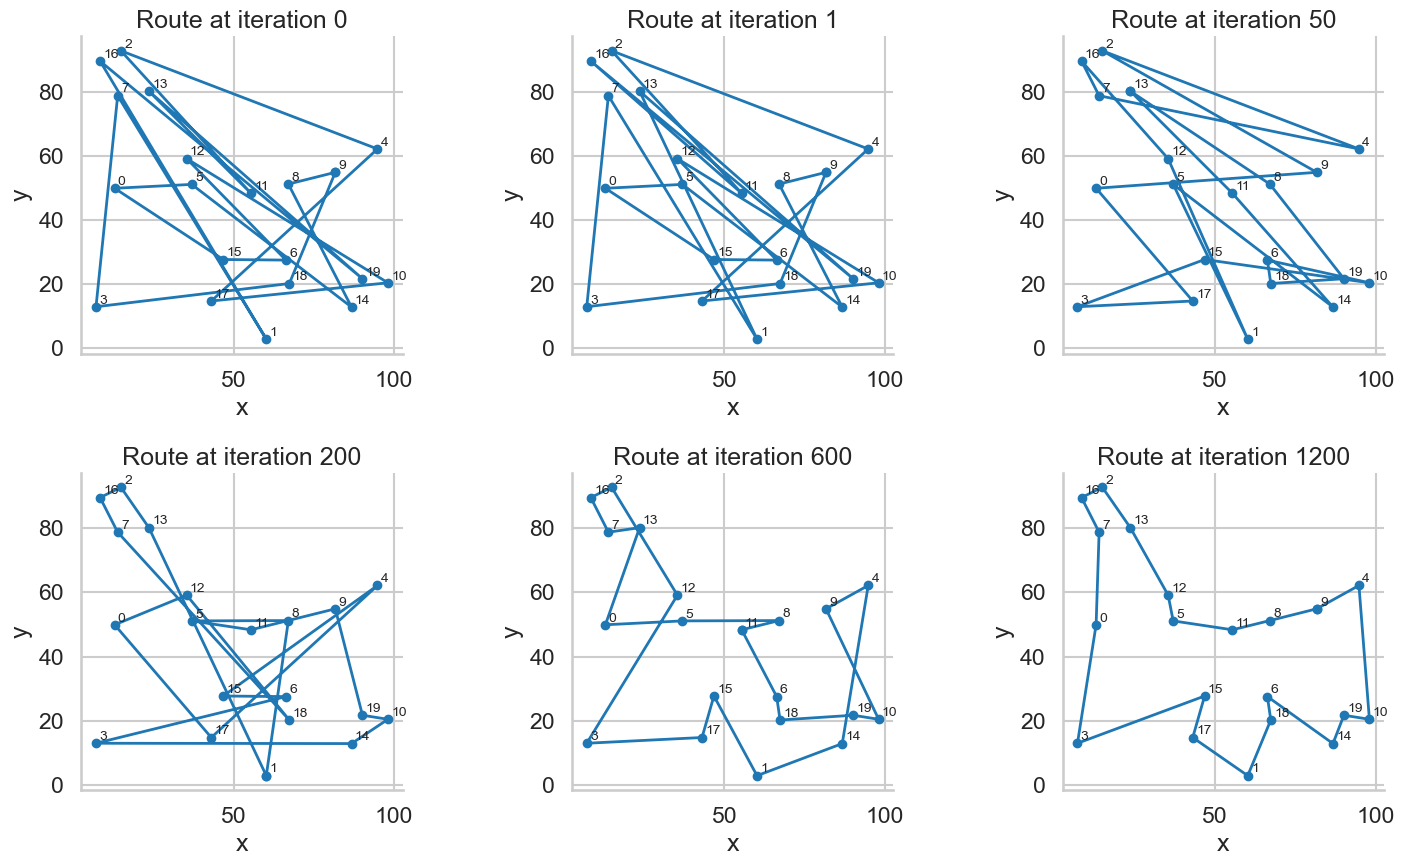

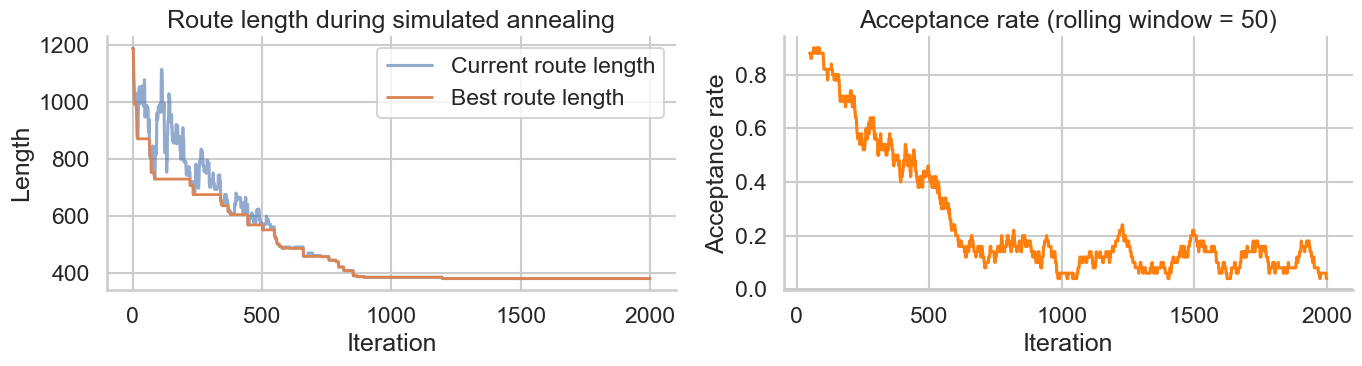

<Figure size 700x700 with 0 Axes>

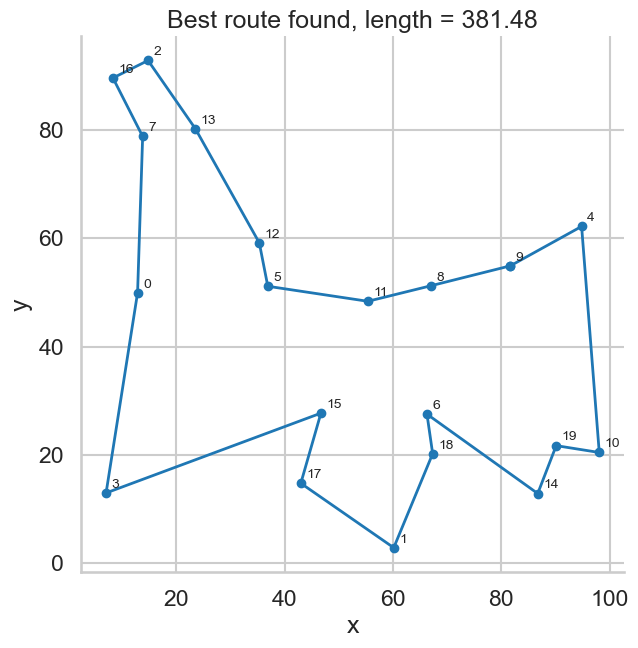

In [3]:
sa_result = simulated_annealing(distance_matrix, seed=5)
print('best route length:', round(sa_result['best_length'], 3))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (iteration, route) in zip(axes.ravel(), sa_result['snapshots']):
    plot_route(cities, route, f'Route at iteration {iteration}', ax=ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(sa_result['current_lengths'], alpha=0.6, label='Current route length')
axes[0].plot(sa_result['best_lengths'], lw=2, label='Best route length')
axes[0].set_title('Route length during simulated annealing')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Length')
axes[0].legend()

window = 50
acceptance_rate = pd.Series(sa_result['accepted_flags']).rolling(window).mean()
axes[1].plot(acceptance_rate, color='tab:orange')
axes[1].set_title(f'Acceptance rate (rolling window = {window})')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Acceptance rate')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
plot_route(cities, sa_result['best_route'], f'Best route found, length = {sa_result["best_length"]:.2f}')
plt.show()

## 多次运行与参数分析

组合优化算法往往带有随机性，因此只看一次结果不够。这里用多次实验和参数敏感性分析来说明算法的稳定性与可调节性。

,Simulated Annealing statistics
best,377.110676
mean,387.196687
worst,405.340141
std,10.295977


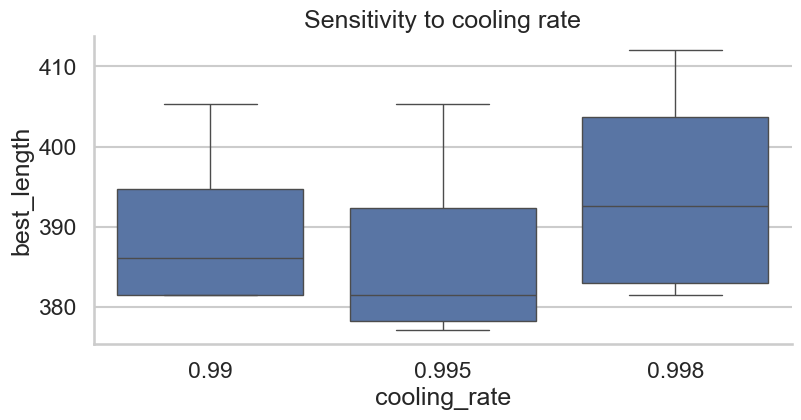

In [4]:
run_scores = [simulated_annealing(distance_matrix, seed=seed)['best_length'] for seed in range(20)]
display(summarize_runs(run_scores).to_frame(name='Simulated Annealing statistics'))

cooling_rates = [0.99, 0.995, 0.998]
records = []
for cooling_rate in cooling_rates:
    for seed in range(10):
        best_length = simulated_annealing(distance_matrix, cooling_rate=cooling_rate, seed=seed)['best_length']
        records.append({'cooling_rate': cooling_rate, 'best_length': best_length})

param_df = pd.DataFrame(records)
plt.figure(figsize=(9, 4))
sns.boxplot(data=param_df, x='cooling_rate', y='best_length')
plt.title('Sensitivity to cooling rate')
plt.show()

## 课堂总结

讲这一类 TSP 实验时，可以让学生反复回答三个问题：

1. 新路径是怎样产生的。
2. 更差的路径何时会被接受，或为什么永远不被接受。
3. 算法如何在“探索新结构”和“保留好结构”之间权衡。